Columns: ['feature', 'reduction', 'n_components', 'trustworthiness', 'continuity', 'pearson_dist_corr', 'spearman_dist_corr', 'stress']


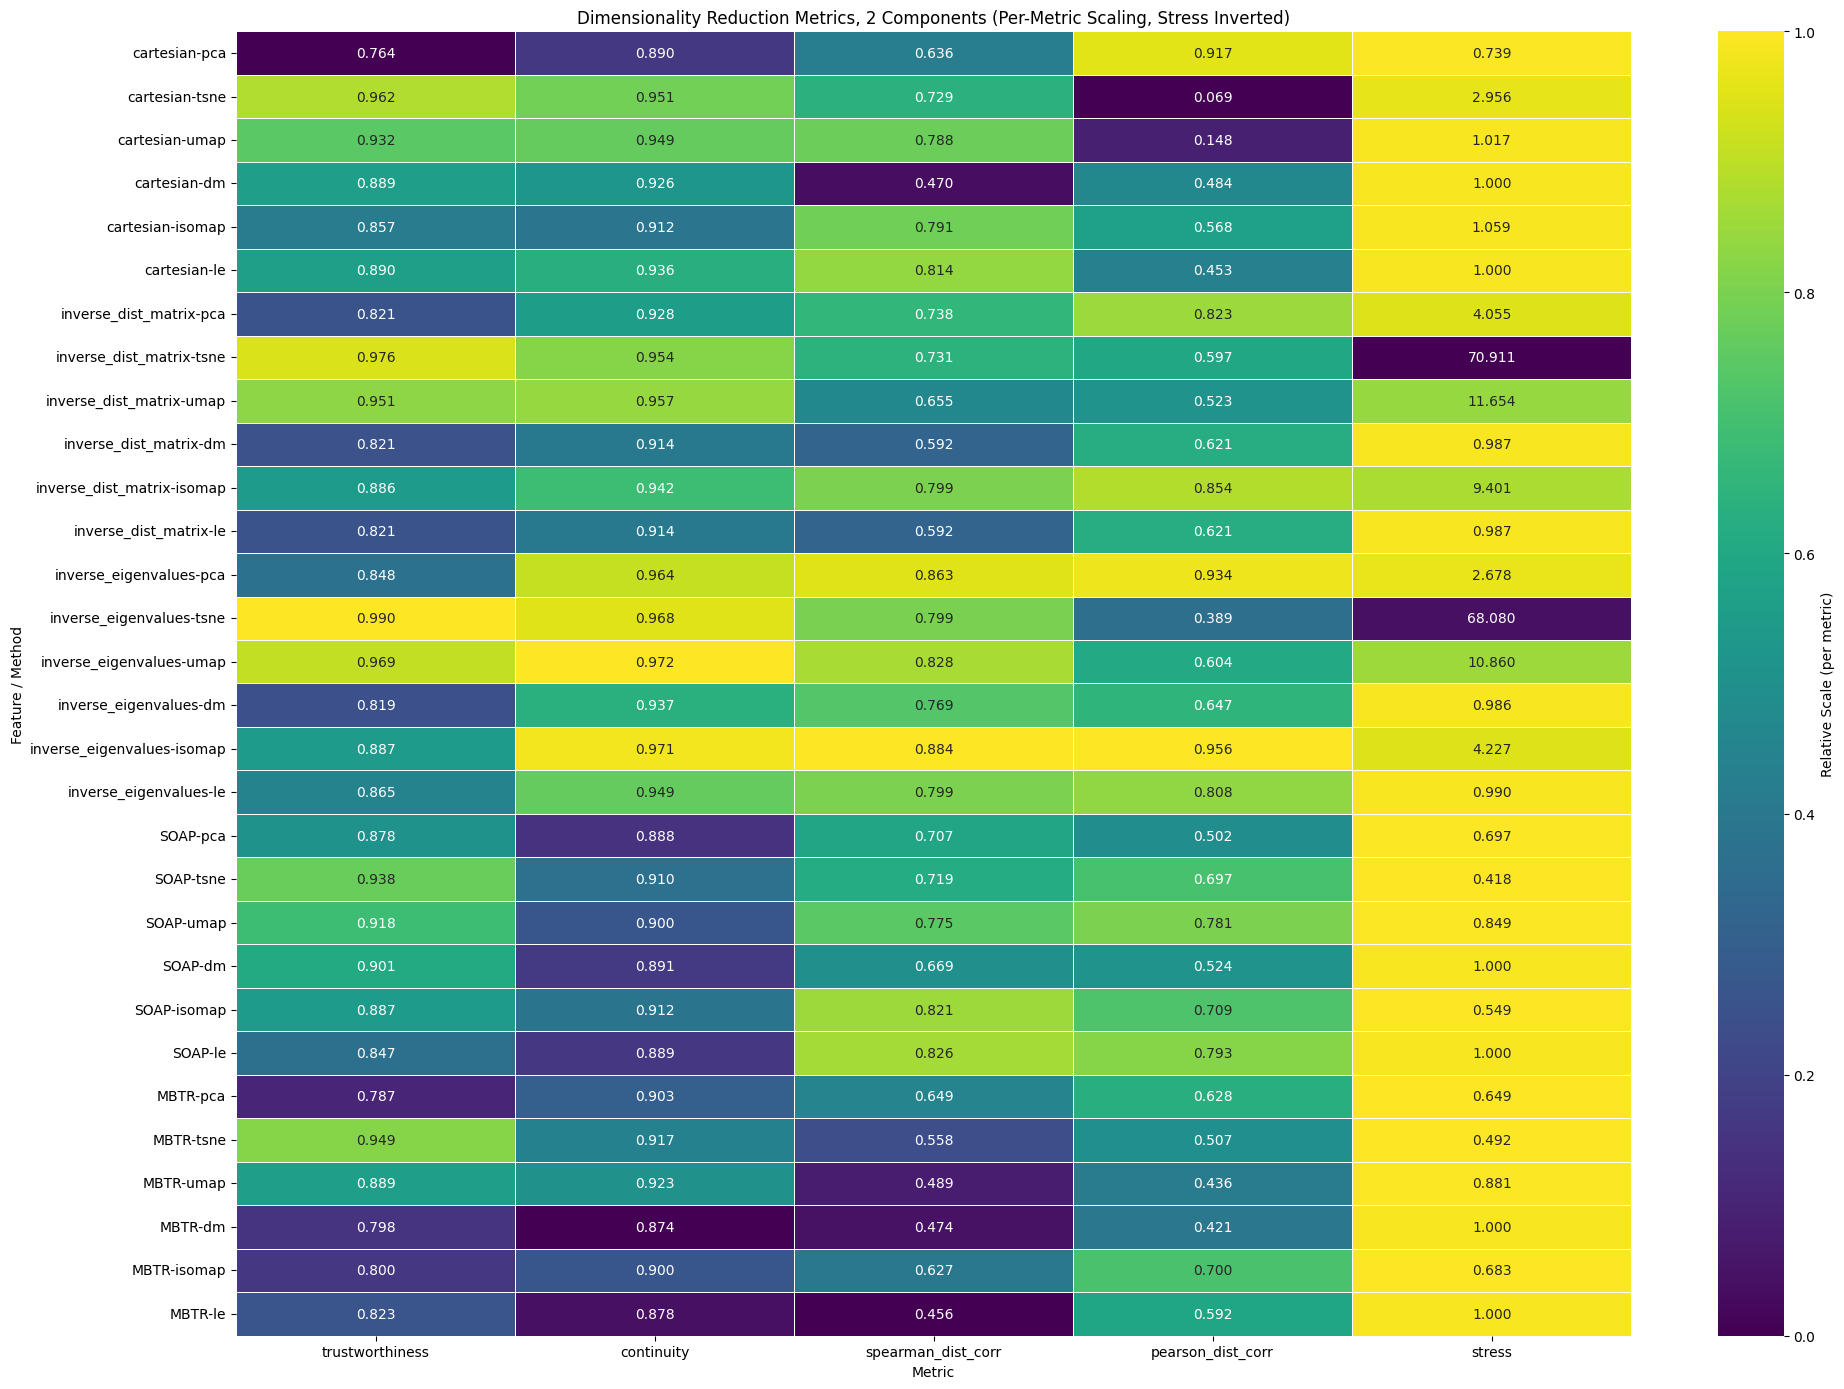

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv(
    "/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/SeamStress/analysis_output/benzene_s1/analysis/embedding_analysis_results.csv",
    sep=","
)

# Clean column names
df.columns = df.columns.str.strip()

print("Columns:", df.columns.tolist())

# Drop unnecessary column safely
df = df.drop(columns=["n_components"], errors="ignore")

# --- Set multi-index: feature + reduction ---
df = df.set_index(["feature", "reduction"])

# Select metrics (only keep existing ones)
desired_metrics = ["trustworthiness", "continuity", "spearman_dist_corr", "pearson_dist_corr","stress"]
metrics = [m for m in desired_metrics if m in df.columns]

heatmap_data = df[metrics].copy()

# --- Normalize per metric ---
norm_data = heatmap_data.copy()

for col in norm_data.columns:
    col_min = norm_data[col].min()
    col_max = norm_data[col].max()

    if col_max != col_min:
        norm_data[col] = (norm_data[col] - col_min) / (col_max - col_min)
    else:
        norm_data[col] = 0.5

    # Invert stress
    if col == "stress":
        norm_data[col] = 1 - norm_data[col]

# Plot
plt.figure(figsize=(20, 14))
sns.heatmap(
    norm_data,
    annot=heatmap_data,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Relative Scale (per metric)"}
)

plt.title("Dimensionality Reduction Metrics, 2 Components (Per-Metric Scaling, Stress Inverted)")
plt.ylabel("Feature / Method")
plt.xlabel("Metric")

plt.tight_layout()
plt.show()